In [1]:
import os
import pandas as pd
from pathlib import Path


In [8]:
df = pd.read_csv('data/raw/2014.csv.zip', compression='zip')
df.head()

/var/folders/hz/j2f56yr91yv_dgnlpwh2b9840000gn/T/ipykernel_16615/1099379590.py:1: DtypeWarning: Columns (0,18,23,24,25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/raw/2014.csv.zip', compression='zip')


,patent_number,grant_year,application_number,application_year,d_inventor,d_assignee,d_location,d_application,d_cpc,d_ipc,...,male_flag7,inventor_id8,inventor_name8,male_flag8,inventor_id9,inventor_name9,male_flag9,inventor_id10,inventor_name10,male_flag10
0,8621662,2014,13175987,2011,1,1,1,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,8621663,2014,12157485,2008,1,1,1,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8621664,2014,13217035,2011,1,0,0,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,8621665,2014,12898200,2010,1,0,0,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8621666,2014,12699804,2010,1,1,1,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df_filtered = df[['patent_number', 'application_year', 'country', 'state', 'county']]
df_filtered.head()

,patent_number,application_year,country,state,county
0,8621662,2011,US,CT,Hartford County
1,8621663,2008,US,NJ,Morris
2,8621664,2011,NaN,NaN,NaN
3,8621665,2010,NaN,NaN,NaN
4,8621666,2010,US,NY,Kings


In [10]:
print(df_filtered['application_year'].unique())

[2011 2008 2010 2012 2013 2007 2009 2006 2003 2004 2002 2005 1998 2000
 2001 1995 1999 1994 1997 2014 1977 1987 1981 1983]


In [4]:
df_filtered.shape

(390438, 5)

In [15]:
def process_patent_zips(raw_data_dir: str) -> pd.DataFrame:
    """
    Reads annualized USPTO patent ZIP files, filters for US inventors,
    and calculates pre-trend and post-shock innovation deltas per county.
    """
    raw_path = Path(raw_data_dir)
    zip_files = sorted(raw_path.glob("*.zip"))
    
    if not zip_files:
        raise FileNotFoundError(f"No .zip files found in {raw_data_dir}. Check your path.")
    
    print(f"Found {len(zip_files)} zip files. Beginning memory-optimized load...")
    
    # The exact columns we need to prevent RAM crashes
    cols_to_keep = ['patent_number', 'application_year', 'country', 'state', 'county']
    df_list = []
    
    # 1. Load and concatenate all zip files
    for file in zip_files:
        print(f"  -> Loading {file.name}...")
        try:
            
            temp_df = pd.read_csv(
                file, 
                usecols=cols_to_keep, 
                dtype={'application_year': 'Int64'} # Handles potential NaNs in years gracefully
            )
            df_list.append(temp_df)
        except Exception as e:
            print(f"  [!] Error reading {file.name}: {e}")
            
    # Combine all years into one massive DataFrame
    print("Concatenating data...")
    full_df = pd.concat(df_list, ignore_index=True)
    
    # 2. Filter and clean
    print("Filtering for US inventors and dropping missing geographies...")
    us_df = full_df[full_df['country'] == 'US'].copy()
    us_df = us_df.dropna(subset=['state', 'county', 'application_year'])
    
    # 3. Group by County and Year
    print("Counting unique patents per county per year...")
    grouped = us_df.groupby(['state', 'county', 'application_year'])['patent_number'].nunique().reset_index()
    grouped = grouped[grouped['application_year']>=2014]
    # 4. Pivot the table so years become columns
    print("Pivoting panel data...")
    pivot_df = grouped.pivot(
        index=['state', 'county'], 
        columns='application_year', 
        values='patent_number'
    ).fillna(0) # If a county had 0 patents in a year, fill with 0
    
    # 5. Calculate the regression variables
    print("Calculating pre-trend and post-shock deltas...")
    
    # Ensure all required year columns exist to prevent KeyError
    required_years = [2014, 2017, 2021, 2022, 2023]
    for year in required_years:
        if year not in pivot_df.columns:
            pivot_df[year] = 0

    # Falsification target: 2017 minus 2014
    pivot_df['delta_pre_trend'] = pivot_df[2017] - pivot_df[2014]
    
    # Main regression target: Average of (2021, 2022, 2023) minus 2017
    # (We average the post-shock years to smooth out single-year volatility)
    pivot_df['delta_post_shock'] = pivot_df[[2021, 2022, 2023]].mean(axis=1) - pivot_df[2017]
    
    # Clean up the index to make it a flat DataFrame again
    final_df = pivot_df.reset_index()
    
    # Ensure column names are strings, not integers, for easier merging later
    final_df.columns = [str(col) if isinstance(col, int) else col for col in final_df.columns]
    
    print(f"Success! Generated local innovation panel with {len(final_df)} counties.")
    
    return final_df

In [16]:
df_patents = process_patent_zips('data/raw')
df_patents.head()

Found 11 zip files. Beginning memory-optimized load...
  -> Loading 2014.csv.zip...


/var/folders/hz/j2f56yr91yv_dgnlpwh2b9840000gn/T/ipykernel_16615/2888377893.py:23: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(


  -> Loading 2015.csv.zip...


/var/folders/hz/j2f56yr91yv_dgnlpwh2b9840000gn/T/ipykernel_16615/2888377893.py:23: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(


  -> Loading 2016.csv.zip...


...

/var/folders/hz/j2f56yr91yv_dgnlpwh2b9840000gn/T/ipykernel_16615/2888377893.py:23: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(


  -> Loading 2024.csv.zip...


/var/folders/hz/j2f56yr91yv_dgnlpwh2b9840000gn/T/ipykernel_16615/2888377893.py:23: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(


Concatenating data...
Filtering for US inventors and dropping missing geographies...
Counting unique patents per county per year...
Pivoting panel data...
Calculating pre-trend and post-shock deltas...
Success! Generated local innovation panel with 2951 counties.


,state,county,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,delta_pre_trend,delta_post_shock
0,AK,Aleutians East,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.000000
1,AK,Anchorage,11.0,19.0,9.0,15.0,16.0,9.0,10.0,7.0,0.0,1.0,0.0,4.0,-12.333333
2,AK,Anchorage Municipality,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.666667
3,AK,Fairbanks North Star,4.0,2.0,1.0,0.0,2.0,0.0,3.0,0.0,1.0,0.0,0.0,-4.0,0.333333
4,AK,Fairbanks North Star Borough,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,1.000000


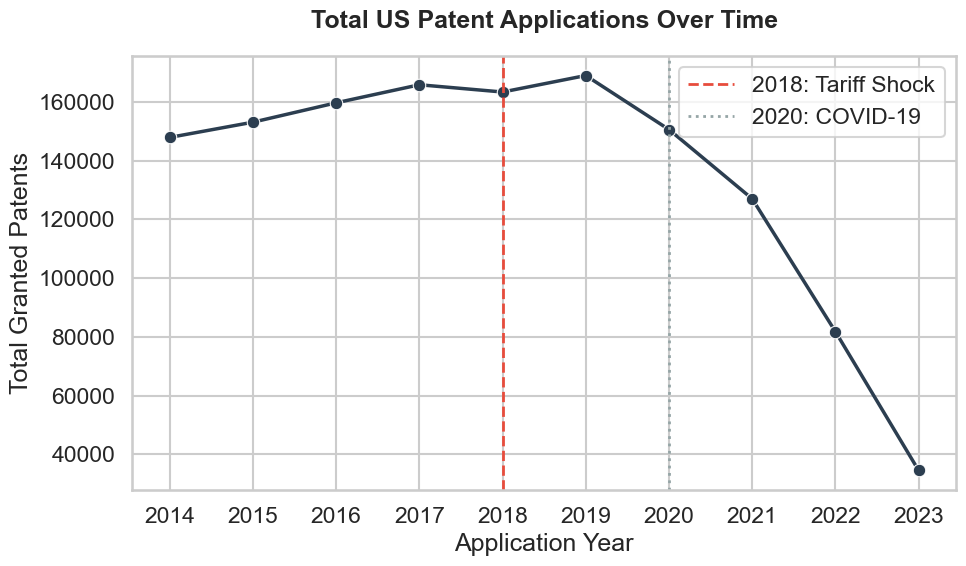

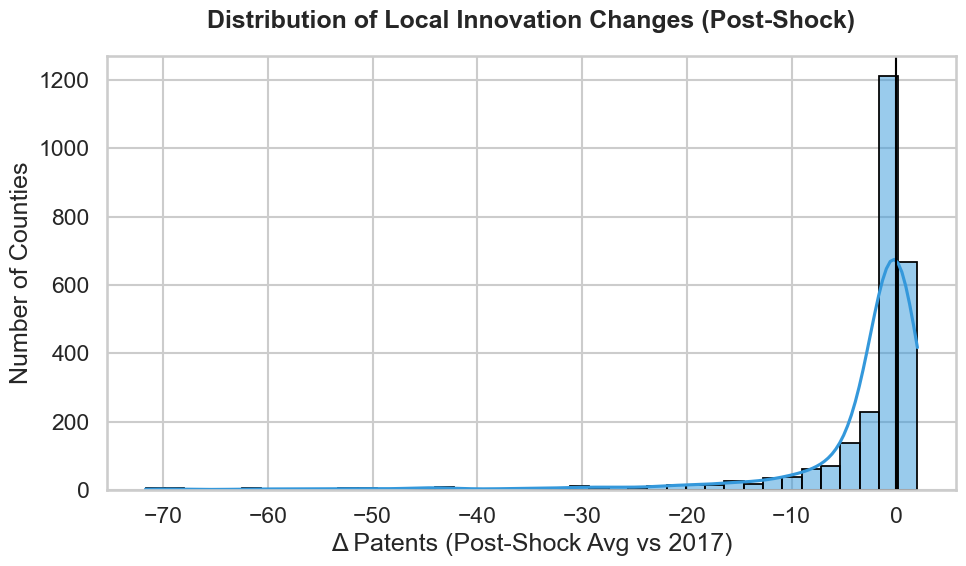

/var/folders/hz/j2f56yr91yv_dgnlpwh2b9840000gn/T/ipykernel_16615/3459814745.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=extremes, x='delta_post_shock', y='Location', palette=colors)


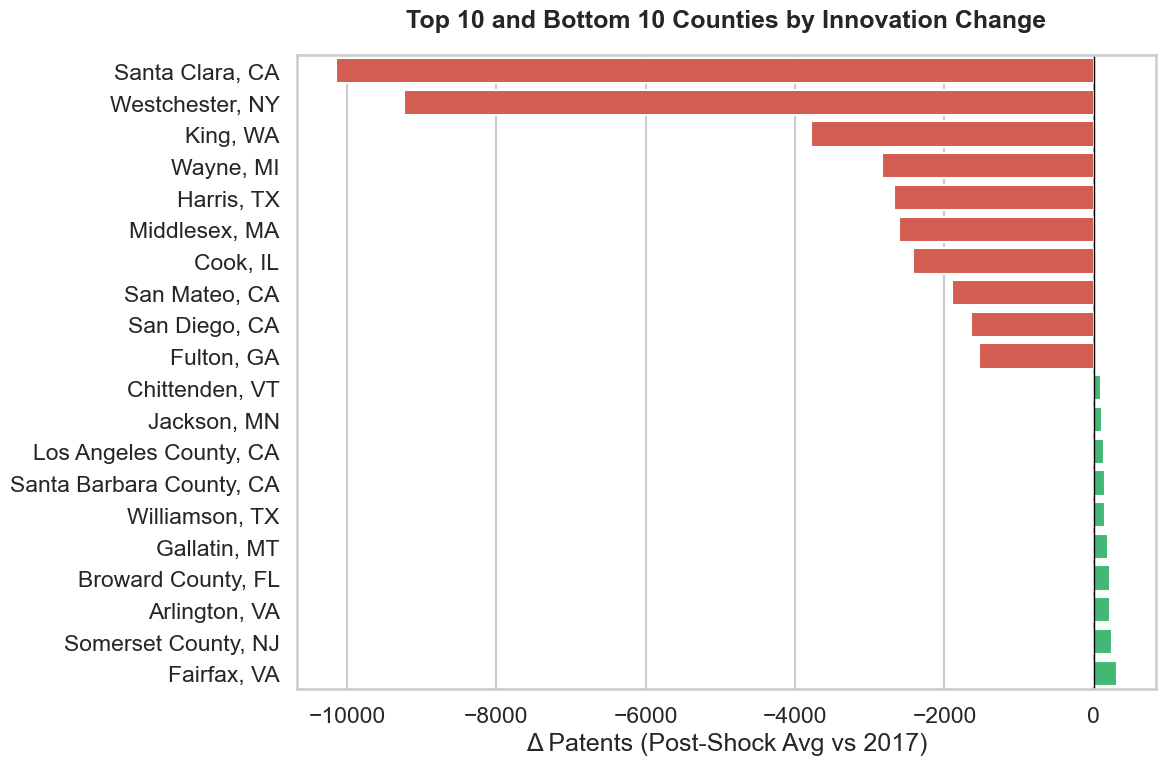

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os



# Set the visual style for professional quant charts
sns.set_theme(style="whitegrid", context="talk")

df = df_patents

# Create a clean label for the charts (e.g., "Santa Clara, CA")
df['Location'] = df['county'] + ", " + df['state']

# ==========================================
# Chart 1: The Aggregate National Heartbeat
# ==========================================
plt.figure(figsize=(10, 6))

# Identify year columns (assuming they are strings like '2014', '2015')
# We will look at 2014 through 2023
years = [str(y) for y in range(2014, 2024)] 

# Sum all counties for each year
national_totals = df[years].sum()

sns.lineplot(x=years, y=national_totals.values, marker="o", color="#2c3e50", linewidth=2.5)

# Add our shock lines
plt.axvline(x="2018", color="#e74c3c", linestyle="--", linewidth=2, label="2018: Tariff Shock")
plt.axvline(x="2020", color="#95a5a6", linestyle=":", linewidth=2, label="2020: COVID-19")

plt.title("Total US Patent Applications Over Time", pad=20, fontweight='bold')
plt.xlabel("Application Year")
plt.ylabel("Total Granted Patents")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/figures/national_heartbeat.png", dpi=300)
plt.show()

# ==========================================
# Chart 2: Winners vs. Losers Distribution
# ==========================================
plt.figure(figsize=(10, 6))

# Filter out the extreme outliers (e.g., Silicon Valley) just so the histogram is readable
lower_bound = df['delta_post_shock'].quantile(0.05)
upper_bound = df['delta_post_shock'].quantile(0.95)
filtered_df = df[(df['delta_post_shock'] >= lower_bound) & (df['delta_post_shock'] <= upper_bound)]

sns.histplot(filtered_df['delta_post_shock'], bins=40, kde=True, color="#3498db", edgecolor="black")

plt.axvline(x=0, color="black", linestyle="-", linewidth=1.5)
plt.title("Distribution of Local Innovation Changes (Post-Shock)", pad=20, fontweight='bold')
plt.xlabel("Δ Patents (Post-Shock Avg vs 2017)")
plt.ylabel("Number of Counties")
plt.tight_layout()
plt.savefig("outputs/figures/innovation_distribution.png", dpi=300)
plt.show()

# ==========================================
# Chart 3: Top 10 and Bottom 10 Shifters
# ==========================================
plt.figure(figsize=(12, 8))

# Get the extremes
top_10 = df.nlargest(10, 'delta_post_shock')
bottom_10 = df.nsmallest(10, 'delta_post_shock')

# Combine them and sort so the chart flows from biggest loser to biggest winner
extremes = pd.concat([bottom_10, top_10]).sort_values(by='delta_post_shock', ascending=True)

# Create a color palette: Red for negative, Green for positive
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in extremes['delta_post_shock']]

sns.barplot(data=extremes, x='delta_post_shock', y='Location', palette=colors)

plt.axvline(x=0, color="black", linestyle="-", linewidth=1)
plt.title("Top 10 and Bottom 10 Counties by Innovation Change", pad=20, fontweight='bold')
plt.xlabel("Δ Patents (Post-Shock Avg vs 2017)")
plt.ylabel("")
plt.tight_layout()
#plt.savefig("outputs/figures/top_bottom_shifters.png", dpi=300)
plt.show()

In [18]:
import pandas as pd

# 1. Define the paths to your replication datasets
# Update these paths based on where you saved the RTP data folder
master_county_path = "data/raw/master_county.dta"
tariffs_naics_path = "data/raw/tariffs_naics.dta"

try:
    # 2. Load the datasets
    print("Loading datasets...")
    df_county = pd.read_stata(master_county_path)
    df_tariffs = pd.read_stata(tariffs_naics_path)
    
    # 3. Inspect the Tariffs file (The Shock: G_j)
    print("\n" + "="*40)
    print(f"TARIFFS DATA (Shape: {df_tariffs.shape})")
    print("="*40)
    print("Columns:", df_tariffs.columns.tolist()[:15]) # Print first 15 columns
    print(df_tariffs.head(3))
    
    # 4. Inspect the County file (The Controls & potentially The Shares: s_ij)
    print("\n" + "="*40)
    print(f"MASTER COUNTY DATA (Shape: {df_county.shape})")
    print("="*40)
    
    # The crucial "Share Matrix Test"
    # If the number of columns is massive (e.g., 300+), the shares are likely in here.
    if len(df_county.columns) > 100:
        print(f"🚨 SUCCESS: You have {len(df_county.columns)} columns! The raw NAICS shares are likely in here.")
        # Let's find columns that look like they represent industry shares (e.g., 'emp', 'share', 'naics')
        share_cols = [col for col in df_county.columns if 'share' in col.lower() or 'naics' in col.lower()]
        print(f"\nPotential Share Columns found ({len(share_cols)}):")
        print(share_cols[:20], "... (truncated)")
    else:
        print(f"⚠️ WARNING: You only have {len(df_county.columns)} columns.")
        print("This file likely only contains the final calculated exposures, not the raw share matrix needed for ssaggregate.")
        print("\nColumns:", df_county.columns.tolist())
        
except FileNotFoundError as e:
    print(f"File not found. Please check your file paths: {e}")

Loading datasets...

TARIFFS DATA (Shape: (686, 15))
Columns: ['naics', 'naics_str', 'naics_desc', 'R0_2017', 'S0_2017', 'E0_2017', 'T0_2017', 'R0_2018', 'S0_2018', 'E0_2018', 'T0_2018', 'R0', 'S0', 'E0', 'T0']
   naics naics_str                                     naics_desc  R0_2017  \
0   11.0        11     Agriculture, Forestry, Fishing and Hunting      0.0   
1   21.0        21  Mining, Quarrying, and Oil and Gas Extraction      0.0   
2   31.0                                                               0.0   

    S0_2017   E0_2017  T0_2017   R0_2018   S0_2018   E0_2018   T0_2018  \
0  0.000083  0.000103      0.0  0.072475  0.003897  0.003537  0.004758   
1  0.000001  0.000001      0.0  0.007579  0.000034  0.000024  0.000041   
2  0.003050  0.003256      0.0  0.011139  0.013903  0.012810  0.012462   

         R0        S0        E0        T0  
0  0.072475  0.003814  0.003434  0.004758  
1  0.007579  0.000032  0.000023  0.000041  
2  0.011139  0.010853  0.009554  0.012462  

MA